In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

## Download Azure Functions Dataset
Source: https://github.com/Azure/AzurePublicDataset/blob/master/AzureFunctionsDataset2019.md


In [ ]:
!wget https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/azurefunctions_dataset2019/azurefunctions-dataset2019.tar.xz
!tar -xJf azurefunctions-dataset2019.tar.xz --one-top-level
!rm azurefunctions-dataset2019.tar.xz

--2025-05-30 13:11:03--  https://azurepublicdatasettraces.blob.core.windows.net/azurepublicdatasetv2/azurefunctions_dataset2019/azurefunctions-dataset2019.tar.xz
Resolving azurepublicdatasettraces.blob.core.windows.net (azurepublicdatasettraces.blob.core.windows.net)... 52.239.236.228
Connecting to azurepublicdatasettraces.blob.core.windows.net (azurepublicdatasettraces.blob.core.windows.net)|52.239.236.228|:443... 

connected.
HTTP request sent, awaiting response... 200 OK
Length: 142968140 (136M) [application/octet-stream]
Saving to: ‘azurefunctions-dataset2019.tar.xz’

azurefunctions-data 100%[===================>] 136.34M  28.6MB/s    in 5.1s    

2025-05-30 13:11:08 (26.6 MB/s) - ‘azurefunctions-dataset2019.tar.xz’ saved [142968140/142968140]



In [13]:
TRACE_DIR = Path('azurefunctions-dataset2019')

## SnapStart Simulation (Fig 13)

In [ ]:
def read_app_memory(day: str):
    prefix = 'app_memory'
    app_memory_df = None
    for filename in os.listdir(TRACE_DIR):
        if filename.startswith(prefix) and day in filename:
            print('Reading', filename)
            app_memory_df = pd.read_csv(TRACE_DIR / filename)[['HashApp','SampleCount','AverageAllocatedMb']]
            break
            
    print('Total rows:', len(app_memory_df))
    return app_memory_df

def read_function_durations(day: str):
    prefix = 'function_durations'
    function_durations_df = None
    for filename in os.listdir(TRACE_DIR):
        if filename.startswith(prefix) and day in filename:
            print('Reading', filename)
            function_durations_df = pd.read_csv(TRACE_DIR / filename)[['HashApp','Average','Count']]
            break
            
    print('Total rows:', len(function_durations_df))
    return function_durations_df

def merge_function_durations(df):
    merged_df = pd.DataFrame({'HashApp': [], 'Average': [], 'Count': []})

    existing_apps = set()

    for i, row in df.iterrows():
        hash_app = row['HashApp']
        if hash_app not in existing_apps:
            if row['Average'] <= 0:
                continue
            new_row = pd.DataFrame({'HashApp': [hash_app], 'Average': [row['Average']], 'Count': [row['Count']]})
            merged_df = pd.concat([merged_df, new_row], ignore_index=True)
            existing_apps.add(hash_app)
        else:
            if row['Average'] <= 0:
                continue
            cur_row = merged_df.loc[merged_df['HashApp'] == hash_app]
            merged_df.loc[merged_df['HashApp'] == hash_app, 'Average'] = (cur_row['Average'] * cur_row['Count'] + row['Average'] * row['Count']) / (cur_row['Count'] + row['Count'])
            merged_df.loc[merged_df['HashApp'] == hash_app, 'Count'] = cur_row['Count'] + row['Count']
    
    print('Total rows:', len(merged_df))
    return merged_df

def read_invocations(day: str, keep_alive_time: int=15):
    prefix = 'invocations'
    invocations_df = None
    for filename in os.listdir(TRACE_DIR):
        if prefix in filename and day in filename:
            print('Reading', filename)
            invocations_df = pd.read_csv(TRACE_DIR / filename)
            break
    
    counts = []
    cold_starts_col_1 = []
    cold_starts_col_10 = []
    cold_starts_col_15 = []
    cold_starts_col_100 = []
    for i, row in invocations_df.iterrows():
        num_cold_starts_10 = 0 # If the function has not been invoked in the last `keep_alive_time` minutes, it is a cold start
        num_cold_starts_1 = 0
        num_cold_starts_15 = 0
        num_cold_starts_100 = 0
        count = 0
        for minute_idx in range(1440):
            cur_col_idx = minute_idx + 4 # there are 4 columns before the first time column
            cur_num_invoke = int(row[cur_col_idx])
            count += cur_num_invoke

            if cur_num_invoke > 0:
                if minute_idx == 0:
                    num_cold_starts_1 += 1 # First minute is always a cold start
                    num_cold_starts_10 += 1
                    num_cold_starts_15 += 1
                    num_cold_starts_100 += 1
                    continue

                keep_alive_time = 1
                start_idx = max(cur_col_idx - keep_alive_time, 4)
                if sum(row[start_idx:cur_col_idx]) == 0:
                    num_cold_starts_1 += 1
                
                keep_alive_time = 10
                start_idx = max(cur_col_idx - keep_alive_time, 4)
                if sum(row[start_idx:cur_col_idx]) == 0:
                    num_cold_starts_10 += 1
                
                keep_alive_time = 15
                start_idx = max(cur_col_idx - keep_alive_time, 4)
                if sum(row[start_idx:cur_col_idx]) == 0:
                    num_cold_starts_15 += 1
                
                keep_alive_time = 100
                start_idx = max(cur_col_idx - keep_alive_time, 4)
                if sum(row[start_idx:cur_col_idx]) == 0:
                    num_cold_starts_100 += 1
        cold_starts_col_1.append(num_cold_starts_1)
        cold_starts_col_10.append(num_cold_starts_10)
        cold_starts_col_15.append(num_cold_starts_15)
        cold_starts_col_100.append(num_cold_starts_100)
        counts.append(count)
    invocations_df['Count'] = counts
    invocations_df['ColdStarts1'] = cold_starts_col_1
    invocations_df['ColdStarts10'] = cold_starts_col_10
    invocations_df['ColdStarts15'] = cold_starts_col_15
    invocations_df['ColdStarts100'] = cold_starts_col_100
    invocations_df = invocations_df[['HashApp', 'Count', 'ColdStarts1', 'ColdStarts10','ColdStarts15', 'ColdStarts100']]
    
    print('Total rows:', len(invocations_df))
    return invocations_df

def merge_invocations(df):
    merged_df = pd.DataFrame({'HashApp': [], 'Count': [], 'ColdStarts1': [], 'ColdStarts10': [], 'ColdStarts15': [], 'ColdStarts100': []})

    existing_apps = set()

    for i, row in df.iterrows():
        hash_app = row['HashApp']
        if hash_app not in existing_apps:
            new_row = pd.DataFrame({'HashApp': [hash_app], 'Count': [row['Count']], 'ColdStarts1': [row['ColdStarts1']], 'ColdStarts10': [row['ColdStarts10']], 'ColdStarts15': [row['ColdStarts15']], 'ColdStarts100': [row['ColdStarts100']]})
            merged_df = pd.concat([merged_df, new_row], ignore_index=True)
            existing_apps.add(hash_app)
        else:
            cur_row = merged_df.loc[merged_df['HashApp'] == hash_app]
            merged_df.loc[merged_df['HashApp'] == hash_app, 'Count'] = cur_row['Count'] + row['Count']
            merged_df.loc[merged_df['HashApp'] == hash_app, 'ColdStarts1'] = cur_row['ColdStarts1'] + row['ColdStarts1']
            merged_df.loc[merged_df['HashApp'] == hash_app, 'ColdStarts10'] = cur_row['ColdStarts10'] + row['ColdStarts10']
            merged_df.loc[merged_df['HashApp'] == hash_app, 'ColdStarts15'] = cur_row['ColdStarts15'] + row['ColdStarts15']
            merged_df.loc[merged_df['HashApp'] == hash_app, 'ColdStarts100'] = cur_row['ColdStarts100'] + row['ColdStarts100']
    
    merged_df['WarmStarts10'] = merged_df['Count'] - merged_df['ColdStarts10']
    merged_df['WarmStarts15'] = merged_df['Count'] - merged_df['ColdStarts15']
    
    print('Total rows:', len(merged_df))
    return merged_df

def read_function_durations(day: str):
    prefix = 'function_durations'
    function_durations_df = None
    for filename in os.listdir(TRACE_DIR):
        if filename.startswith(prefix) and day in filename:
            print('Reading', filename)
            function_durations_df = pd.read_csv(TRACE_DIR / filename)[['HashApp','Average','Count']]
            break
            
    print('Total rows:', len(function_durations_df))
    return function_durations_df

def merge_function_durations(df):
    merged_df = pd.DataFrame({'HashApp': [], 'Average': [], 'Count': []})

    existing_apps = set()

    for i, row in df.iterrows():
        hash_app = row['HashApp']
        if hash_app not in existing_apps:
            if row['Average'] <= 0:
                continue
            new_row = pd.DataFrame({'HashApp': [hash_app], 'Average': [row['Average']], 'Count': [row['Count']]})
            merged_df = pd.concat([merged_df, new_row], ignore_index=True)
            existing_apps.add(hash_app)
        else:
            if row['Average'] <= 0:
                continue
            cur_row = merged_df.loc[merged_df['HashApp'] == hash_app]
            merged_df.loc[merged_df['HashApp'] == hash_app, 'Average'] = (cur_row['Average'] * cur_row['Count'] + row['Average'] * row['Count']) / (cur_row['Count'] + row['Count'])
            merged_df.loc[merged_df['HashApp'] == hash_app, 'Count'] = cur_row['Count'] + row['Count']
    
    print('Total rows:', len(merged_df))
    return merged_df
def get_duration_and_memory(day: str):
    app_memory_df = read_app_memory(day)
    merged_duration_df = merge_function_durations(read_function_durations(day))
    merged_df = pd.merge(app_memory_df, merged_duration_df, on='HashApp')
    return merged_df


In [ ]:
PRICE_PER_MS_PER_MB_PER_100K_REQ = 0.00000162109
CACHE_PRICE_PER_MB_SECOND = 0.0000015046 / 1000
RESTOR_PRICE_PER_MB = 0.0001397998 / 1000

def calculate_cost(day: str, kepp_alive_time: int=15):
    app_memory_df = read_app_memory(day)
    function_durations_df = merge_function_durations(read_function_durations(day))
    function_invocations_df = merge_invocations(read_invocations(day, kepp_alive_time))
    function_invocations_df = function_invocations_df[['HashApp', 'ColdStarts1', 'ColdStarts10','ColdStarts15', 'ColdStarts100', 'WarmStarts10']]

    merged_df = pd.merge(app_memory_df, function_durations_df, on='HashApp')
    merged_df = pd.merge(merged_df, function_invocations_df, on='HashApp')

    apps = []
    invocation_cost = []
    cache_cost = []
    restore_cost_1 = []
    restore_cosst_10 = []
    restore_cost_15 = []
    restore_cost_20 = []
    snap_start_cost_ratio_1 = []
    snap_start_cost_ratio_10 = []
    snap_start_cost_ratio_15 = []
    snap_start_cost_ratio_20 = []

    for i, row in merged_df.iterrows():
        apps.append(row['HashApp'])
        i_cost = row['Average'] * row['Count'] * row['AverageAllocatedMb'] * PRICE_PER_MS_PER_MB_PER_100K_REQ / 100000
        invocation_cost.append(i_cost)

        cache_time = 24 * 60 # Cache charges the whole duration when the function is active
        c_cost = cache_time * row['AverageAllocatedMb'] * CACHE_PRICE_PER_MB_SECOND
        cache_cost.append(c_cost)

        r_cost_1 = row['ColdStarts1'] * row['AverageAllocatedMb'] * RESTOR_PRICE_PER_MB
        restore_cost_1.append(r_cost_1)
        snap_start_cost_ratio_1.append((c_cost + r_cost_1)/(i_cost + c_cost + r_cost_1))

        r_cost_10 = row['ColdStarts10'] * row['AverageAllocatedMb'] * RESTOR_PRICE_PER_MB
        restore_cosst_10.append(r_cost_10)
        snap_start_cost_ratio_10.append((c_cost + r_cost_10)/(i_cost + c_cost + r_cost_10))

        r_cost_15 = row['ColdStarts15'] * row['AverageAllocatedMb'] * RESTOR_PRICE_PER_MB
        restore_cost_15.append(r_cost_15)
        snap_start_cost_ratio_15.append((c_cost + r_cost_15)/(i_cost + c_cost + r_cost_15))

        r_cost_20 = row['ColdStarts100'] * row['AverageAllocatedMb'] * RESTOR_PRICE_PER_MB
        restore_cost_20.append(r_cost_20)
        snap_start_cost_ratio_20.append((c_cost + r_cost_20)/(i_cost + c_cost + r_cost_20))

        
    
    cost_df = pd.DataFrame({'HashApp': apps, 'InvocationCost': invocation_cost, 'CacheCost': cache_cost, 'RestoreCost1': restore_cost_1, 'SnapStartCostRatio1': snap_start_cost_ratio_1, 'RestoreCost10': restore_cosst_10, 'SnapStartCostRatio10': snap_start_cost_ratio_10, 'RestoreCost15': restore_cost_15, 'SnapStartCostRatio15': snap_start_cost_ratio_15, 'RestoreCost100': restore_cost_20, 'SnapStartCostRatio100': snap_start_cost_ratio_20})

    print('Total rows:', len(cost_df))
    print(f"Avg invocation cost: {sum(invocation_cost) / len(invocation_cost)}, avg cache cost: {sum(cache_cost) / len(cache_cost)}, avg restore cost 1: {sum(restore_cost_1) / len(restore_cost_1)}, avg restore cost 10: {sum(restore_cosst_10) / len(restore_cosst_10)}, avg restore cost 15: {sum(restore_cost_15) / len(restore_cost_15)}, avg restore cost 20: {sum(restore_cost_20) / len(restore_cost_20)}.average snap start cost ratio 1: {sum(snap_start_cost_ratio_1) / len(snap_start_cost_ratio_1)}, average snap start cost ratio 10: {sum(snap_start_cost_ratio_10) / len(snap_start_cost_ratio_10)}, average snap start cost ratio 15: {sum(snap_start_cost_ratio_15) / len(snap_start_cost_ratio_15)}, average snap start cost ratio 20: {sum(snap_start_cost_ratio_20) / len(snap_start_cost_ratio_20)}, ")
    return cost_df

# May take 30 minutes to run
cost_df = calculate_cost('d01')

Reading app_memory_percentiles.anon.d01.csv
Total rows: 17275
Reading function_durations_percentiles.anon.d01.csv
Total rows: 49728
Total rows: 17383
Reading invocations_per_function_md.anon.d01.csv


/tmp/ipykernel_288352/56892486.py:70: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cur_num_invoke = int(row[cur_col_idx])


Total rows: 46412
Total rows: 17577
Total rows: 16914
Avg invocation cost: 0.20056209769705083, avg cache cost: 0.00034802791049308186, avg restore cost 1: 0.0044448676174349815, avg restore cost 10: 0.0006017014056376144, avg restore cost 15: 0.0003648047678876316, avg restore cost 20: 9.668298438674452e-05.average snap start cost ratio 1: 0.7122904415661248, average snap start cost ratio 10: 0.5906623449336448, average snap start cost ratio 15: 0.574206932877723, average snap start cost ratio 20: 0.5402879664119051, 


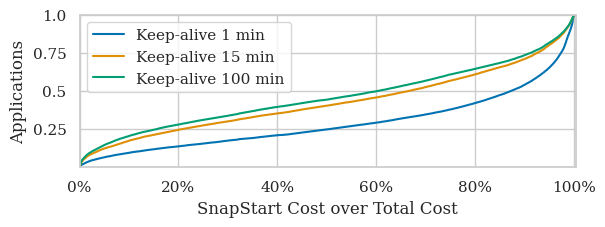

In [30]:
columns = ['SnapStartCostRatio1', 'SnapStartCostRatio15', 'SnapStartCostRatio100']
legend_labels = {
    'SnapStartCostRatio1': 'Keep-alive 1 min',
    'SnapStartCostRatio15': 'Keep-alive 15 min',
    'SnapStartCostRatio100': 'Keep-alive 100 min',
}
colors = sns.color_palette("colorblind", len(columns))  # Get distinct colors

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rc("font", size=18, family="serif")


for col, color in zip(columns, colors):
    sorted_data = np.sort(cost_df[col].dropna())

    # Ensure CDF starts at (0,0) and ends at (1,1)
    if sorted_data[0] > 0:
        sorted_data = np.insert(sorted_data, 0, 0)  # Insert (0,0) at the start
    if sorted_data[-1] < 1:
        sorted_data = np.append(sorted_data, 1)  # Append 1 to ensure it reaches (1,1)

    cdf = np.arange(len(sorted_data)) / (len(sorted_data) - 1)  # Normalize to reach exactly 1

    # Plot CDF with color
    sns.lineplot(x=sorted_data, y=cdf, color=color, label=legend_labels[col])

# Labels
plt.xlabel('SnapStart Cost over Total Cost')
plt.ylabel('Applications')

plt.gca().set_xticks(np.linspace(0, 1, 6))  # Define tick positions for x-axis
plt.gca().set_xticklabels([f"{int(tick * 100)}%" for tick in np.linspace(0, 1, 6)])  # Format x-axis as %

plt.gca().set_yticks(np.linspace(0.25, 1, 4))  # Define tick positions
plt.gca().set_yticklabels([tick for tick in np.linspace(0.25, 1, 4)])

plt.xlim(0, 1.004)
plt.ylim(0, 1)
plt.gca().set_aspect('0.309', adjustable='box')

output_dir = Path('figures')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "fig13.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Simulating SnapStart with AzureTrace and ServerlessBench applications (Fig 14)

In [31]:
def get_app_mapping(duration_mem_df):
    duration_mem_df = get_duration_and_memory('d01')
    app_stats_df = pd.read_csv('csv/original_summary.csv')
    app_mapping = dict()
    for i, row in app_stats_df.iterrows():
        app_name = row['app']
        min_distance = float('inf')
        min_distance_hash = None
        for j, row2 in duration_mem_df.iterrows():
            l2_distance = (row2['Average'] - row['e2e_latency']) ** 2 + (row2['AverageAllocatedMb'] - row['memory']) ** 2
            if l2_distance < min_distance:
                min_distance = l2_distance
                min_distance_hash = row2['HashApp']
        print(f"app: {app_name}, hash: {min_distance_hash}, distance: {min_distance}")
        app_mapping[app_name] = min_distance_hash
    return app_mapping

In [ ]:
PRICE_PER_MS_PER_MB_PER_100K_REQ = 0.00000162109
CACHE_PRICE_PER_MB_SECOND = 0.0000015046 / 1000
RESTOR_PRICE_PER_MB = 0.0001397998 / 1000

def merge_app_with_stats(function_invocations_df):
    duration_mem_df = get_duration_and_memory('d01')
    app_mapping = get_app_mapping(duration_mem_df)
    function_invocations_df = function_invocations_df[['HashApp', 'ColdStarts15', 'WarmStarts15']]

    app_hash_df = pd.DataFrame({
        'app': list(app_mapping.keys()),
        'HashApp': list(app_mapping.values())
    })

    merged_df = pd.merge(function_invocations_df, app_hash_df, on='HashApp')

    return merged_df

# May take 30 minutes to run
invocations_df = merge_invocations(read_invocations('d01'))
app_stats_df = merge_app_with_stats(invocations_df)


Reading invocations_per_function_md.anon.d01.csv


/tmp/ipykernel_288352/56892486.py:70: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cur_num_invoke = int(row[cur_col_idx])


Total rows: 46412
Total rows: 17577
Reading app_memory_percentiles.anon.d01.csv
Total rows: 17275
Reading function_durations_percentiles.anon.d01.csv
Total rows: 49728
Total rows: 17383
Reading app_memory_percentiles.anon.d01.csv
Total rows: 17275
Reading function_durations_percentiles.anon.d01.csv
Total rows: 49728
Total rows: 17383
app: chdb-olap, hash: 70e71ed372a2859170cd0c3476a16e4e0b161d19b68ab5d5dd7222f063f458ab, distance: 215.07445113218176
app: dna-visualization, hash: 90ccb65ada5953b0996f43609b9de119a419d18204d9f0d78355e8b62d8a4faf, distance: 904.8185000000001
app: epub-pdf, hash: 1b61ac3838950c2ea28d46c8989567c4796e3bc4c9d2c5dea9f88482f77e2b24, distance: 0.3139999999999956
app: ffmpeg, hash: 7eae40b54e3bbb9a17d32885bdec11b92fc137f8a1bddd00fecee57c9efebfbb, distance: 277.4689000000001
app: huggingface, hash: 8920728b3de1e77e35461bd3dfa8a94617d53e08fec6136a030c7bad5f06b7c3, distance: 26570.993524048026
app: igraph, hash: 90ccb65ada5953b0996f43609b9de119a419d18204d9f0d78355e8b6

,HashApp,ColdStarts15,WarmStarts15,app
0,1b61ac3838950c2ea28d46c8989567c4796e3bc4c9d2c5...,1.0,11519.0,epub-pdf
1,90ccb65ada5953b0996f43609b9de119a419d18204d9f0...,1.0,481.0,dna-visualization
2,90ccb65ada5953b0996f43609b9de119a419d18204d9f0...,1.0,481.0,igraph
3,90ccb65ada5953b0996f43609b9de119a419d18204d9f0...,1.0,481.0,lxml
4,90ccb65ada5953b0996f43609b9de119a419d18204d9f0...,1.0,481.0,markdown
5,90ccb65ada5953b0996f43609b9de119a419d18204d9f0...,1.0,481.0,shapely-numpy
6,274f6fb01d22723a28441f3d840422bf8ecc4183c59377...,1.0,1439.0,jsym
7,28bf4860667c2922c07bf36624f6d8e74b1da11f7b106f...,1.0,287.0,skimage
8,8920728b3de1e77e35461bd3dfa8a94617d53e08fec613...,7.0,84915.0,huggingface
9,8920728b3de1e77e35461bd3dfa8a94617d53e08fec613...,7.0,84915.0,resnet


In [33]:

debloated_summary_df = pd.read_csv('csv/debloated_summary.csv')
original_summary_df = pd.read_csv('csv/original_summary.csv')
warm_cost_df = pd.read_csv('csv/warm_cost.csv')

apps = debloated_summary_df['app']

# Reorder rows in the apps_stats df to match the order of apps. num_cold_starts and num_warm_starts follow this order
num_cold_starts =[]
num_warm_starts = []
for app_name in apps:
    row = app_stats_df.loc[app_stats_df['app'] == app_name]
    num_cold_starts.append(row['ColdStarts15'].values[0])
    num_warm_starts.append(row['WarmStarts15'].values[0])

num_warm_starts = np.array(num_warm_starts)
num_cold_starts = np.array(num_cold_starts)

invocation_cost_debloat = (debloated_summary_df['cost'] * num_cold_starts + warm_cost_df['debloated'] * num_warm_starts) / 100000 # unit price is for 100k requests
invocation_cost_original = (original_summary_df['cost'] * num_cold_starts + warm_cost_df['original'] * num_warm_starts) / 100000

snap_start_cost_debloat =  num_cold_starts * RESTOR_PRICE_PER_MB * debloated_summary_df['memory'] + CACHE_PRICE_PER_MB_SECOND * 24*60*60 * debloated_summary_df['memory']
snap_start_cost_original =  num_cold_starts * RESTOR_PRICE_PER_MB * original_summary_df['memory'] + CACHE_PRICE_PER_MB_SECOND * 24*60*60 * original_summary_df['memory']

Average improvement: 10.711441415193402. max improvement: 41.92643104616419


<Figure size 640x480 with 0 Axes>

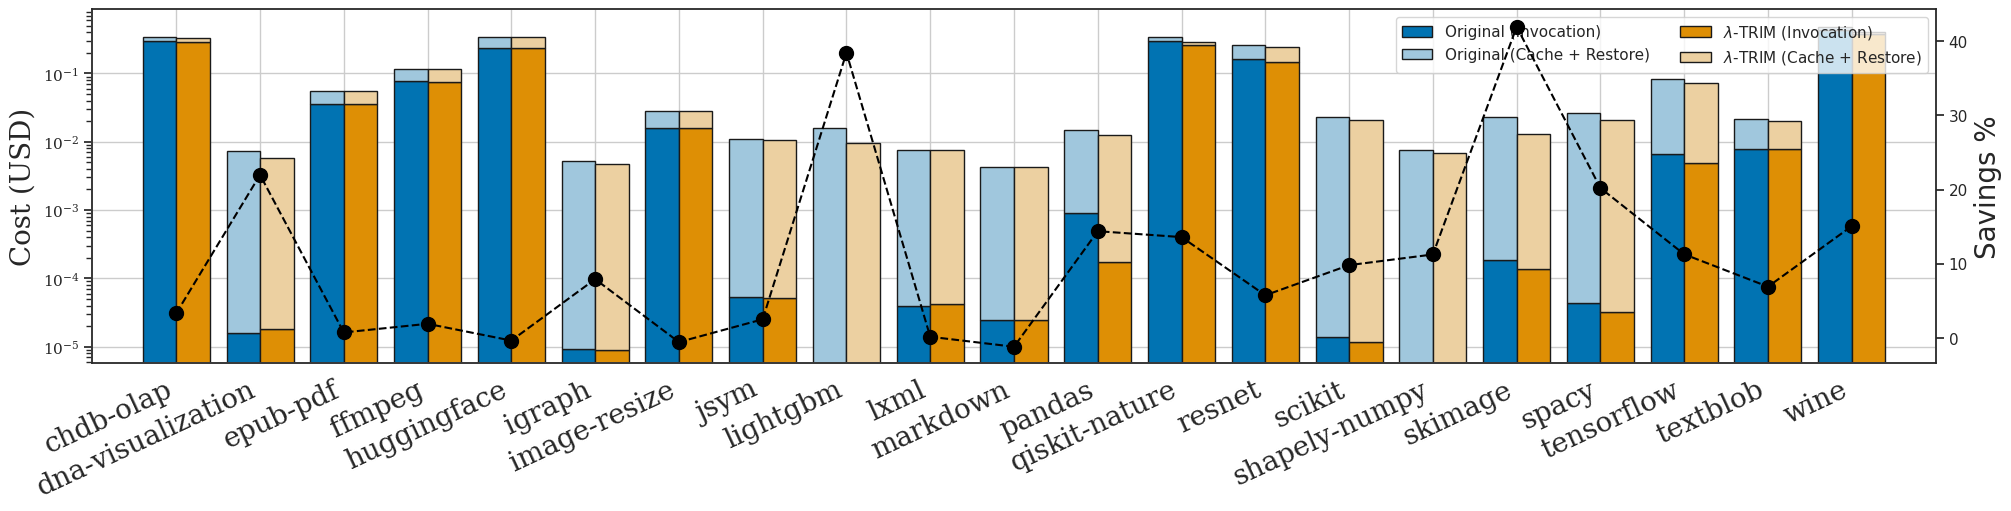

In [34]:
plt.clf()
fig, ax_main = plt.subplots(figsize=(20, 5), layout="constrained")

x_axis = np.arange(len(apps))

colors = sns.color_palette("colorblind", 2) 
color0 = colors[0]
color1 = colors[1]

color0_light = sns.light_palette(color0, 4)[1]
color1_light = sns.light_palette(color1, 4)[1]

sns.set_theme(style="white")


def plot(
    invocation_cost, snap_start_cost, label: str, color: str, hatch: str, contrast: bool = False
):
    dev = -0.2 if label == "Original" else 0.2

    base_color = color0 if label == "Original" else color1
    top_color = color0_light if label == "Original" else color1_light

    with sns.color_palette("colorblind"):
        ax_main.bar(
            x_axis + dev, invocation_cost, 0.4, label=f"{label} (Invocation)", edgecolor="k", color=base_color
        )
        ax_main.bar(
            x_axis + dev,
            snap_start_cost,
            0.4,
            bottom=invocation_cost,
            label=f"{label} (Cache + Restore)",
            edgecolor="k",
            color=top_color,
        )

plot(invocation_cost_original, snap_start_cost_original, "Original", "dimgray", "//")
plot(invocation_cost_debloat, snap_start_cost_debloat, "$\\lambda$-TRIM", "gainsboro", "//")

ax_main.set_xticks(x_axis, apps, rotation=25, ha="right", fontsize=20)
ax_main.set_ylabel("Cost (USD)", fontsize=20)
ax_main.set_yscale("log")
ax_main.legend(ncol=2)

improvements = [
        (ori - deb) * 100 / ori
        for (ori, deb) in zip(
            invocation_cost_original + snap_start_cost_original,
            invocation_cost_debloat + snap_start_cost_debloat,
        )
    ]

print(f"Average improvement: {sum(improvements) / len(improvements)}. max improvement: {max(improvements)}")

ax_impr = ax_main.twinx()
ax_impr.plot(
    x_axis,
    improvements,
    color="black",
    marker="o",
    markersize=10,
    linestyle="--"
)

ax_impr.set_xlim(-1, len(apps))
ax_impr.set_ylabel("Savings %", fontsize=20)
ymin, ymax = ax_impr.set_ylim()
ax_impr.set_ylim(ymin, ymax + 0.2)

plt.rc("font", size=20, family="serif")
output_dir = Path('figures')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "fig14.pdf")
plt.show()